In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

import math

In [2]:
df = pd.read_csv("monthly_milk_production.csv")

In [3]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [5]:
df.isnull().sum()

,0
Date,0
Production,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.set_index("Date", inplace=True)
df.head()

,Production
Date,
1962-01,589
1962-02,561
1962-03,640
1962-04,656
1962-05,727


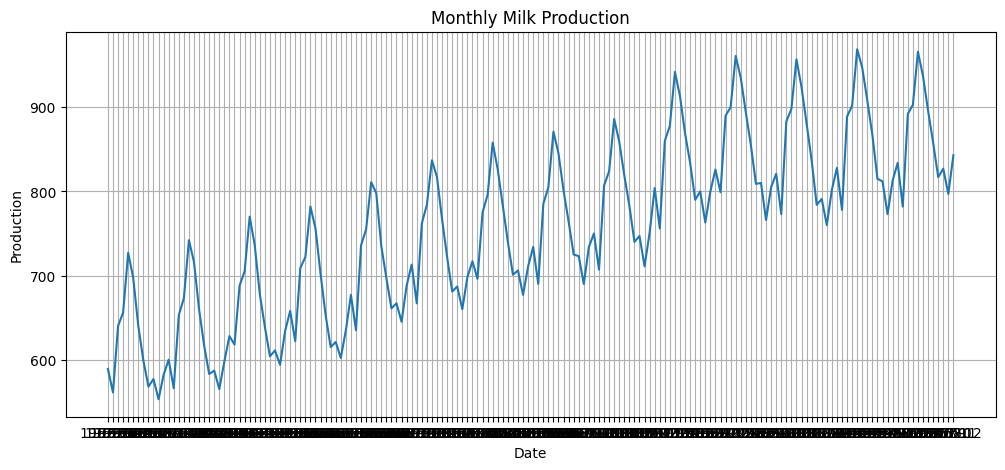

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Production"])
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.grid(True)
plt.show()

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

In [10]:
sequence_length = 12

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

In [11]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)
print(y.shape)

(156, 12, 1)
(156,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)

(124, 12, 1)
(32, 12, 1)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

rnn_model = Sequential()

rnn_model.add(SimpleRNN(50, activation='tanh', input_shape=(12,1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mse')

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1868 - val_loss: 0.0235
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0192 - val_loss: 0.0189
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0077
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0044 - val_loss: 0.0052
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - val_loss: 0.0051
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0028 - val_loss: 0.0033
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0029
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025 - val_loss: 0.0039
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0027 - val_loss: 0.0041
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0024 - va

In [15]:
y_pred = rnn_model.predict(X_test)

print(y_pred[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
[[0.9855041 ]
 [0.95601183]
 [0.86938745]
 [0.79926836]
 [0.67147106]]


In [16]:
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_actual = scaler.inverse_transform(y_pred)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)

RMSE : 21.38797197376187
MAE  : 16.23133659362794
MAPE : 1.9464625421875437


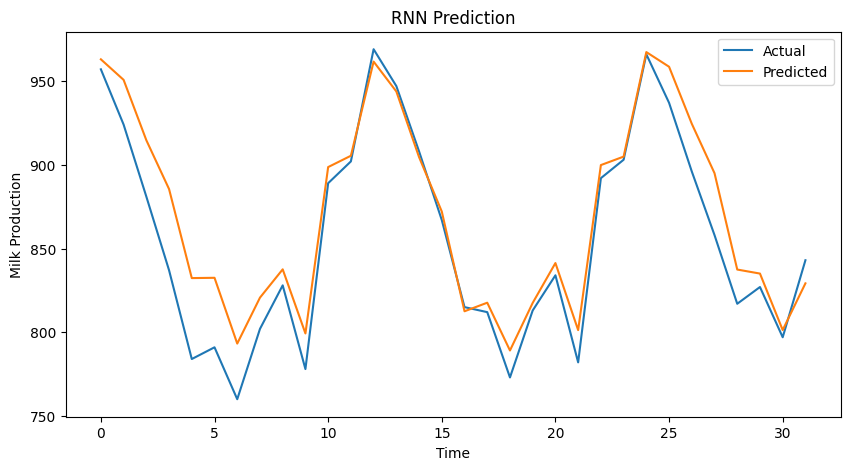

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred_actual, label='Predicted')

plt.title("RNN Prediction")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()

plt.show()

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.1503 - val_loss: 0.1042
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0356 - val_loss: 0.0313
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0242 - val_loss: 0.0320
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0227 - val_loss: 0.0237
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0225 - val_loss: 0.0238
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0220 - val_loss: 0.0238
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0218 - val_loss: 0.0229
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0219 - val_loss: 0.0244
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0221 - val_loss: 0.0227
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0212 - val_loss: 0.0233
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0217 - val_loss: 0.0218
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0221 - val_l

In [20]:
y_pred_lstm = lstm_model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm_actual))
mae = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_lstm_actual)/y_test_actual))*100

print("RMSE :", rmse)
print("MAE :", mae)
print("MAPE :", mape)

RMSE : 33.02560440654682
MAE : 28.256948471069325
MAPE : 3.3220617664842162


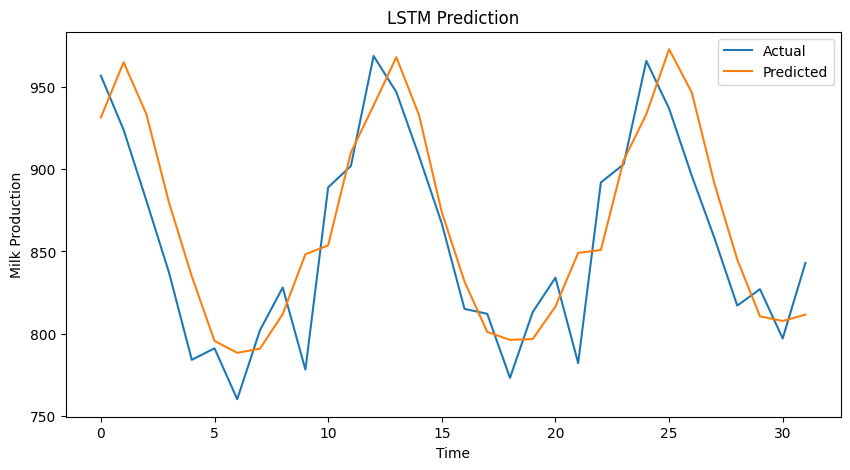

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_lstm_actual, label="Predicted")
plt.title("LSTM Prediction")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential()

gru_model.add(GRU(50, activation='relu', input_shape=(X_train.shape[1], 1)))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.2240 - val_loss: 0.3819
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1203 - val_loss: 0.1791
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0414 - val_loss: 0.0294
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0294 - val_loss: 0.0418
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0246 - val_loss: 0.0337
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0229 - val_loss: 0.0282
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0207 - val_loss: 0.0258
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0201 - val_loss: 0.0204
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0190 - val_loss: 0.0198
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0176 - val_loss: 0.0194
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0165 - val_loss: 0.0173
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0163 - val_l

In [24]:
y_pred_gru = gru_model.predict(X_test)

y_pred_gru_actual = scaler.inverse_transform(y_pred_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_gru = np.sqrt(mean_squared_error(y_test_actual, y_pred_gru_actual))
mae_gru = mean_absolute_error(y_test_actual, y_pred_gru_actual)
mape_gru = np.mean(np.abs((y_test_actual - y_pred_gru_actual) / y_test_actual)) * 100

print("GRU RMSE :", rmse_gru)
print("GRU MAE  :", mae_gru)
print("GRU MAPE :", mape_gru)

GRU RMSE : 32.9166925073044
GRU MAE  : 25.92407226562499
GRU MAPE : 3.0622799655194632


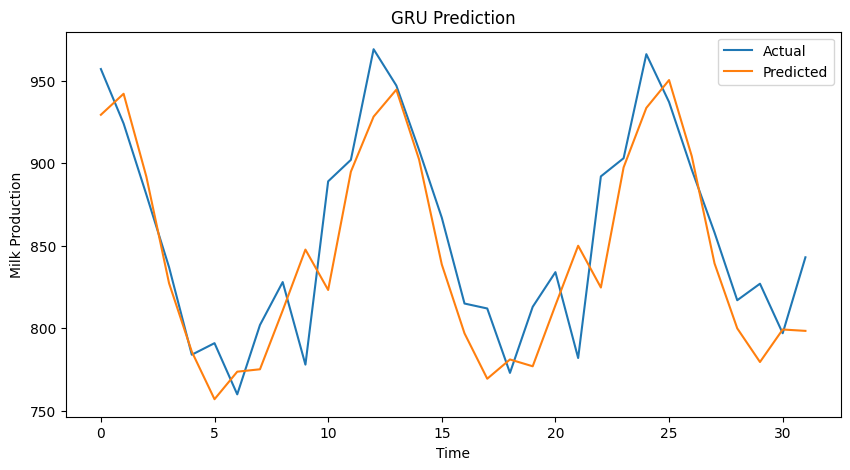

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_gru_actual, label="Predicted")

plt.title("GRU Prediction")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()

plt.show()

In [27]:
print("Conclusion")
print("1. Monthly milk production data was successfully preprocessed.")
print("2. Time-series sequences were created using a 12-month window.")
print("3. RNN, LSTM, and GRU models were built and trained successfully.")
print("4. The models accurately predicted future milk production.")
print("5. RMSE, MAE, and MAPE were used to evaluate forecasting performance.")
print("6. The best-performing model can be used for future milk production forecasting and business planning.")

Conclusion
1. Monthly milk production data was successfully preprocessed.
2. Time-series sequences were created using a 12-month window.
3. RNN, LSTM, and GRU models were built and trained successfully.
4. The models accurately predicted future milk production.
5. RMSE, MAE, and MAPE were used to evaluate forecasting performance.
6. The best-performing model can be used for future milk production forecasting and business planning.
